### Importation of the libraries 

In [2]:
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn 
%pip install scikit-learn 
%pip install torch 
%pip install scikit-optimize 
%pip install xgboost
%pip install openpyxl
%pip install tabulate
%pip install statsmodels
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

### Loading the Data

In [4]:
df = pd.read_excel("Veave - Analyse NTs_Adult_230126-R.xlsx", sheet_name="NTadu-R-stack")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           86 non-null     str    
 1   Cohort           86 non-null     str    
 2   Group            86 non-null     str    
 3   Cage             86 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             86 non-null     str    
 6   Sample Name      0 non-null      float64
 7   Sex              86 non-null     str    
 8   Area             86 non-null     str    
 9   Sample Name.1    86 non-null     str    
 10  5HTP             86 non-null     object 
 11  Adénosine        86 non-null     object 
 12  Adrénaline       2 non-null      str    
 13  Dopamine         86 non-null     object 
 14  GABA             86 non-null     object 
 15  Glutamate        86 non-null     object 
 16  Glutamine        86 non-null     object 
 17  Kynurénine       86 non-null 

In [6]:
mask = df["GABA"].apply(lambda x: isinstance(x, str))
print(df.loc[mask])

   Projet     Cohort Group  Cage  ID  ID.2  Sample Name     Sex Area  \
60  VEAVE  Cohorte 3  CONT    14 NaN  14-6          NaN  Female  HIP   

   Sample Name.1  ... GABA Glutamate Glutamine Kynurénine Noradrénaline  \
60         14-6_  ...    x         x         x          x             x   

   Normétanéphrine Sérotonine Tryptophane Tyramine Tyrosine  
60               x          x           x        x        x  

[1 rows x 24 columns]


In [7]:
df = df[~mask]

In [8]:
df = df.reset_index(drop=True)

In [9]:
df["Dopamine"].map(type).value_counts(dropna=False)
df.loc[df["Dopamine"].map(lambda x: isinstance(x, str)), "Dopamine"]

Series([], Name: Dopamine, dtype: object)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           85 non-null     str    
 1   Cohort           85 non-null     str    
 2   Group            85 non-null     str    
 3   Cage             85 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             85 non-null     str    
 6   Sample Name      0 non-null      float64
 7   Sex              85 non-null     str    
 8   Area             85 non-null     str    
 9   Sample Name.1    85 non-null     str    
 10  5HTP             85 non-null     object 
 11  Adénosine        85 non-null     object 
 12  Adrénaline       2 non-null      str    
 13  Dopamine         85 non-null     object 
 14  GABA             85 non-null     object 
 15  Glutamate        85 non-null     object 
 16  Glutamine        85 non-null     object 
 17  Kynurénine       85 non-null 

In [11]:
nts = [
    "5HTP", "Adénosine", "Adrénaline", "Dopamine", "GABA",
    "Glutamate", "Glutamine", "Kynurénine",
    "Noradrénaline", "Normétanéphrine",
    "Sérotonine", "Tryptophane", "Tyramine", "Tyrosine"
]

for col in nts:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           85 non-null     str    
 1   Cohort           85 non-null     str    
 2   Group            85 non-null     str    
 3   Cage             85 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             85 non-null     str    
 6   Sample Name      0 non-null      float64
 7   Sex              85 non-null     str    
 8   Area             85 non-null     str    
 9   Sample Name.1    85 non-null     str    
 10  5HTP             85 non-null     float64
 11  Adénosine        85 non-null     float64
 12  Adrénaline       0 non-null      float64
 13  Dopamine         85 non-null     float64
 14  GABA             85 non-null     float64
 15  Glutamate        85 non-null     float64
 16  Glutamine        85 non-null     float64
 17  Kynurénine       85 non-null 

In [13]:
df = df[
    ~(
        (df['GABA'] > 21)
    )
]

In [14]:
df = df.drop(index=43)

In [15]:
df = df.reset_index(drop=True)

In [16]:
df["Sex"] = df["Sex"].str.lower()

In [17]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', 'Sample Name.1', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine',
       'GABA', 'Glutamate', 'Glutamine', 'Kynurénine', 'Noradrénaline',
       'Normétanéphrine', 'Sérotonine', 'Tryptophane', 'Tyramine', 'Tyrosine'],
      dtype='str')


### Separation of the Data by Area

In [18]:
NT_df_pfc_adu = df.query("Area == 'PFC'").copy()
NT_df_hip_adu = df.query("Area == 'HIP'").copy()

In [19]:
print(f" --In the PFC group--:",NT_df_pfc_adu['Group'].value_counts())


 --In the PFC group--: Group
LBN     25
CONT    17
Name: count, dtype: int64


In [20]:
print(f" --In the HIP group-- :",NT_df_hip_adu['Group'].value_counts())

 --In the HIP group-- : Group
LBN     24
CONT    17
Name: count, dtype: int64


---

#### For the PFC 

In [21]:
print("For the PFC Area : ")
print(
    NT_df_pfc_adu
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)

For the PFC Area : 
   Group     Sex     Cohort  Cage  N
0   CONT  female  Cohorte 3    14  3
1   CONT  female  Cohorte 3    17  4
2   CONT  female  Cohorte 3    18  3
3   CONT    male  Cohorte 3    13  2
4   CONT    male  Cohorte 3    19  5
5    LBN  female  Cohorte 3    12  3
6    LBN  female  Cohorte 3    16  3
7    LBN  female  Cohorte 3    20  2
8    LBN    male  Cohorte 3    10  5
9    LBN    male  Cohorte 3    11  5
10   LBN    male  Cohorte 3    15  3
11   LBN    male  Cohorte 3    21  4


---

#### For the HIP

In [22]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_adu
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the HIP Area :
   Group     Sex     Cohort  Cage  N
0   CONT  female  Cohorte 3    14  2
1   CONT  female  Cohorte 3    17  4
2   CONT  female  Cohorte 3    18  4
3   CONT    male  Cohorte 3    13  2
4   CONT    male  Cohorte 3    19  5
5    LBN  female  Cohorte 3    12  3
6    LBN  female  Cohorte 3    16  3
7    LBN  female  Cohorte 3    20  2
8    LBN    male  Cohorte 3    10  4
9    LBN    male  Cohorte 3    11  5
10   LBN    male  Cohorte 3    15  3
11   LBN    male  Cohorte 3    21  4


In [23]:
columns_to_drop = ['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex','Area', 'Sample Name.1','Adrénaline']
X_adu_pfc = NT_df_pfc_adu.drop(columns=columns_to_drop)
Y_adu_pfc = NT_df_pfc_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_adu_hip = NT_df_hip_adu.drop(columns=columns_to_drop)
Y_adu_hip = NT_df_hip_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)

#### Transformation Log 

In [28]:
X_adu_pfc_log = np.log1p(X_adu_pfc)
X_adu_hip_log = np.log1p(X_adu_hip)

## Analysis

### Principal Component Analysis (PCA)

---

#### For the PFC

In [35]:
scaler = StandardScaler()
X_adu_pfc_scaled = scaler.fit_transform(X_adu_pfc_log)

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_pfc_pca = pca.fit_transform(X_adu_pfc_scaled)

In [37]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.3473407151043496,
 PCA2 : 0.24555819612769075 
 PCA3 : 0.1297093373728463 
And the sum is: 0.7226082486048867


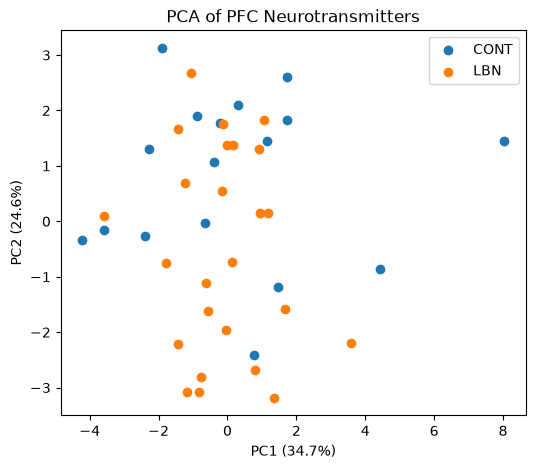

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc ==0, 0],
    X_adu_pfc_pca[Y_adu_pfc ==0, 1],
    label="CONT"
)

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc ==1, 0],
    X_adu_pfc_pca[Y_adu_pfc ==1, 1],
    label="LBN"
)

plt.title("PCA of PFC Neurotransmitters")
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.show()

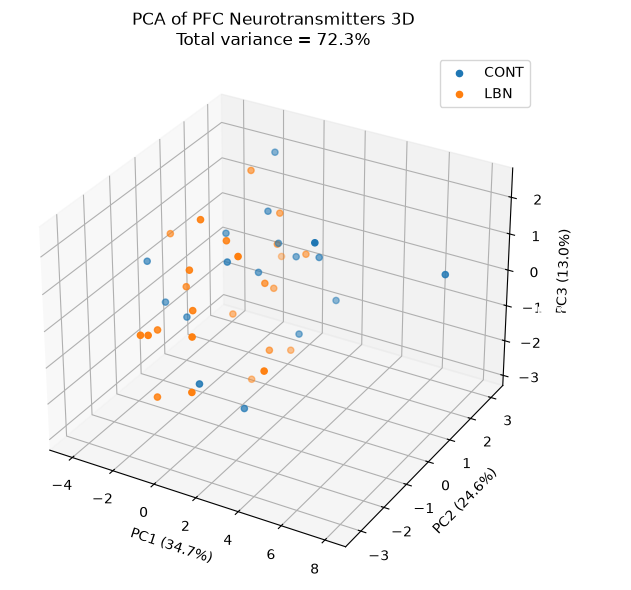

In [39]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==0,0],
    X_adu_pfc_pca[Y_adu_pfc==0,1],
    X_adu_pfc_pca[Y_adu_pfc==0,2],
    label="CONT"
)

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==1,0],
    X_adu_pfc_pca[Y_adu_pfc==1,1],
    X_adu_pfc_pca[Y_adu_pfc==1,2],
    label="LBN"
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"PCA of PFC Neurotransmitters 3D\nTotal variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%"
)

ax.legend()
fig.subplots_adjust(right=0.85)

plt.tight_layout()
ax.text2D(
    1,
    0.5,
    f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)",
    transform=ax.transAxes,
    color="white"
)
plt.show()

In [40]:
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

In [41]:
print(f"Loadings for PC1:\n{loadings_pfc['PC1'].sort_values(key=abs, ascending=False)}")

Loadings for PC1:
Glutamate          0.420799
Tryptophane        0.385859
Glutamine          0.346271
Dopamine           0.339364
5HTP               0.299300
Sérotonine         0.290941
Kynurénine         0.270424
Adénosine          0.259583
Noradrénaline      0.203691
Tyrosine           0.194653
GABA               0.134649
Tyramine           0.117526
Normétanéphrine    0.113607
Name: PC1, dtype: float64


In [42]:
print(f"Loadings for PC2:\n{loadings_pfc['PC2'].sort_values(key=abs, ascending=False)}")

Loadings for PC2:
Normétanéphrine    0.479621
GABA               0.460289
Noradrénaline     -0.416877
Dopamine          -0.308538
Tyrosine           0.285986
Sérotonine        -0.236085
Tyramine           0.200147
Glutamine          0.199052
5HTP              -0.193945
Tryptophane        0.137310
Kynurénine         0.106686
Adénosine         -0.048173
Glutamate         -0.041719
Name: PC2, dtype: float64


In [43]:
print(f"Loadings for PC3:\n{loadings_pfc['PC3'].sort_values(key=abs, ascending=False)}")

Loadings for PC3:
Kynurénine         0.465345
Adénosine         -0.450731
Tyramine           0.358955
5HTP               0.348401
Tyrosine          -0.303632
Noradrénaline     -0.265963
GABA              -0.252277
Normétanéphrine   -0.194085
Tryptophane        0.148963
Sérotonine        -0.134182
Glutamine          0.116115
Dopamine          -0.108638
Glutamate         -0.018501
Name: PC3, dtype: float64


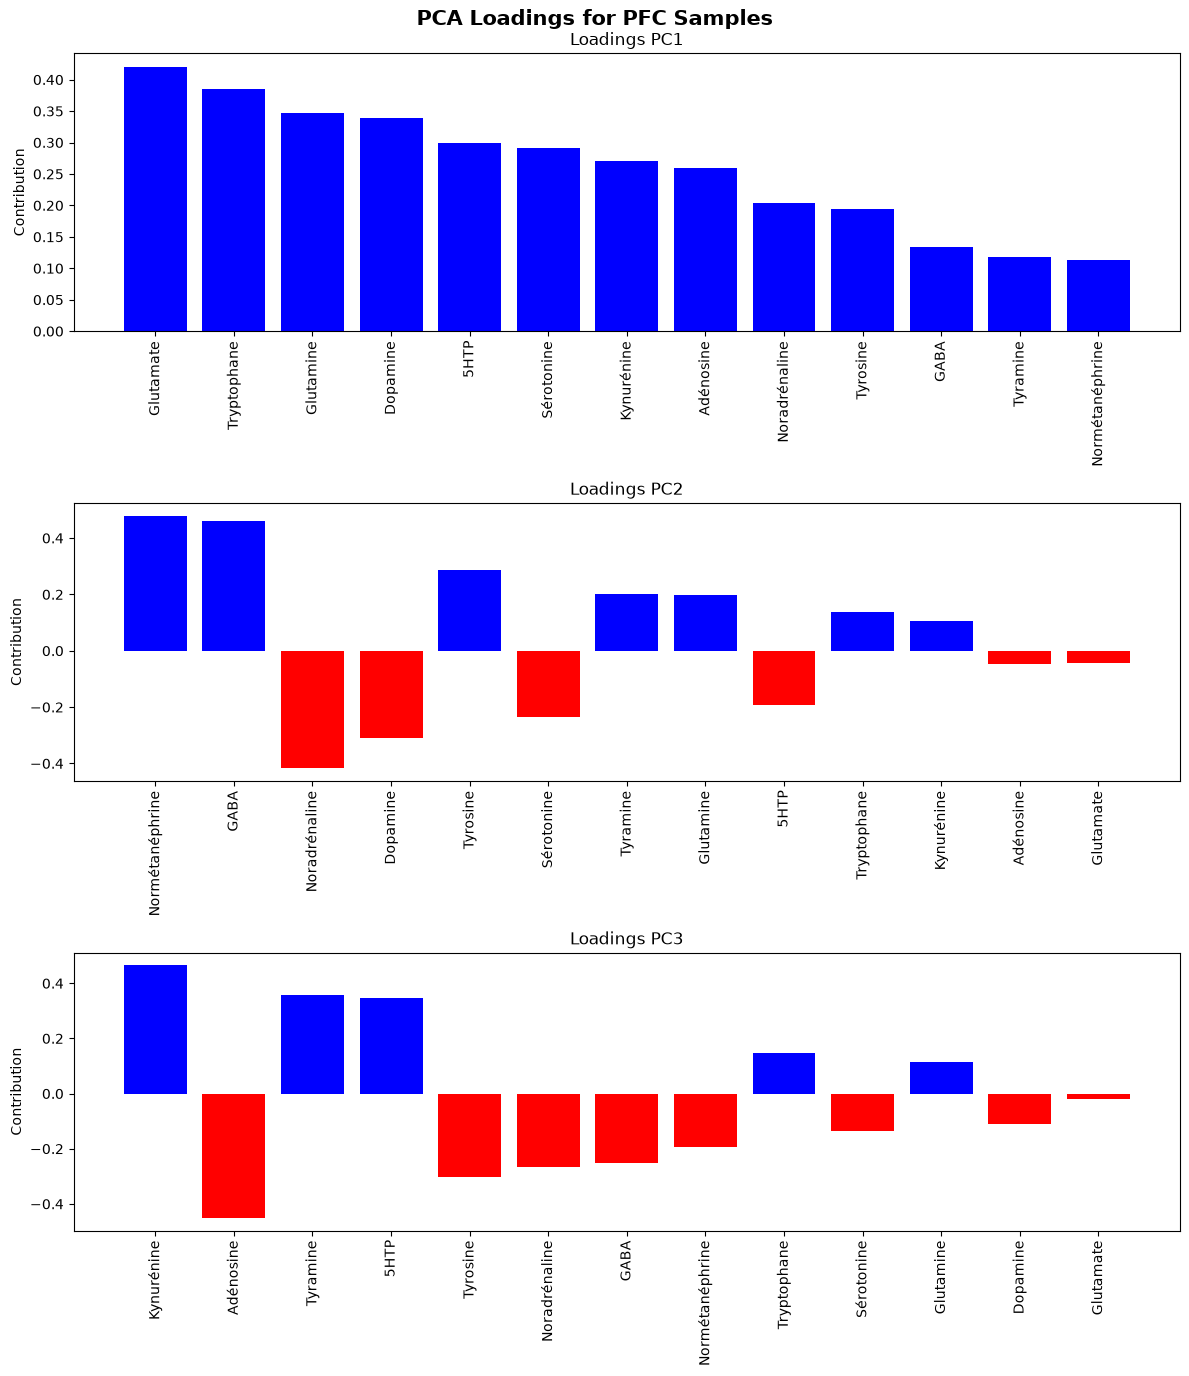

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Loadings PCA
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

# Figure
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
)
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    # tri par valeur absolue
    values = loadings_pfc[pc].sort_values(key=abs, ascending=False)
    
    # couleurs selon le signe
    colors = ["red" if v < 0 else "blue" for v in values.values]
    
    axes[i].bar(values.index, values.values, color=colors)
    axes[i].set_title(f"Loadings {pc}")
    axes[i].set_ylabel("Contribution")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

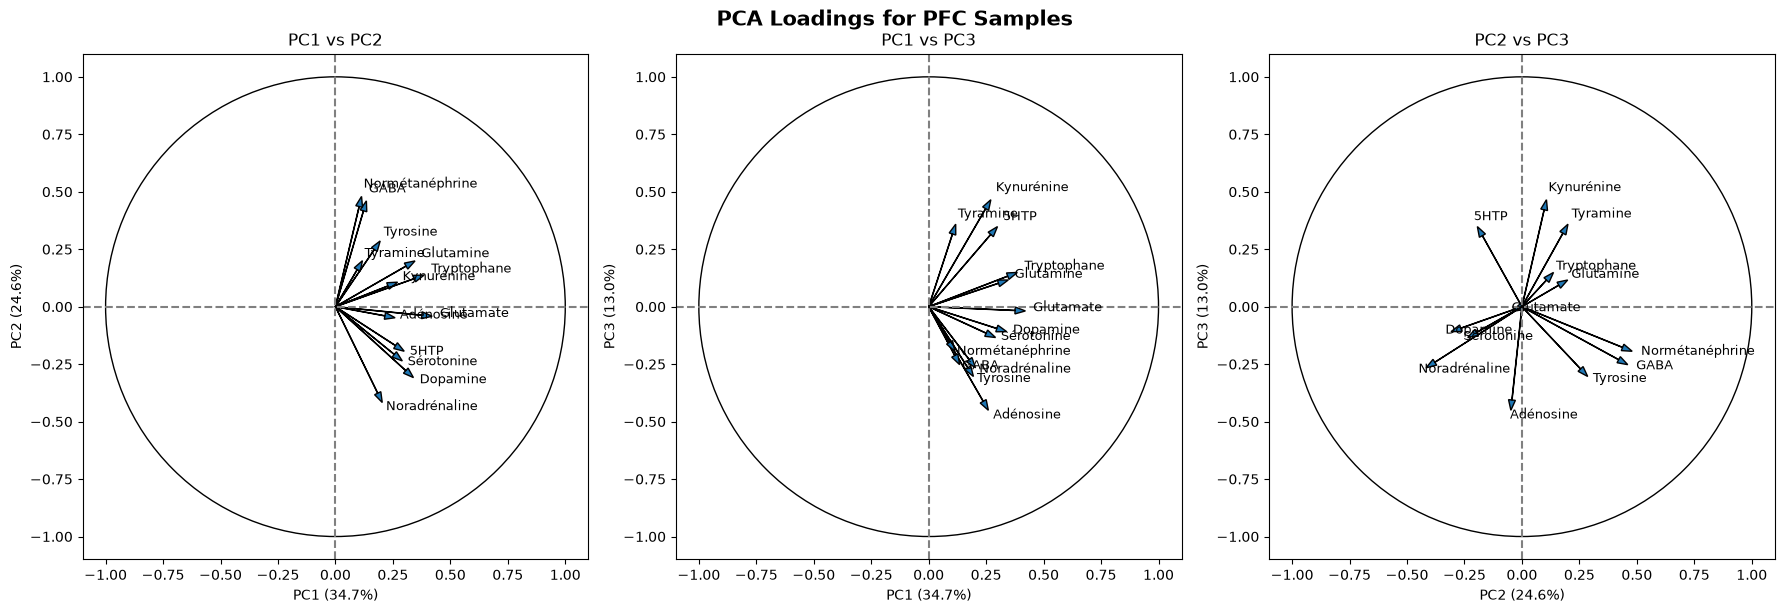

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_pfc.index:

        x = loadings_pfc.loc[nt, pcx]
        y = loadings_pfc.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the HIP 

In [46]:
scaler = StandardScaler()
X_adu_hip_scaled = scaler.fit_transform(X_adu_hip_log)

In [47]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_hip_pca = pca.fit_transform(X_adu_hip_scaled)

In [48]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.34091387827498576,
 PCA2 : 0.1853005891938515 
 PCA3 : 0.13933317972161524 
And the sum is: 0.6655476471904525


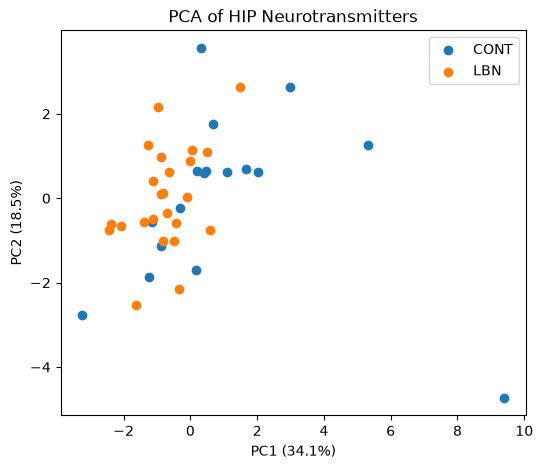

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_hip_pca[Y_adu_hip ==0, 0],
    X_adu_hip_pca[Y_adu_hip ==0, 1],
    label="CONT"
)

plt.scatter(
    X_adu_hip_pca[Y_adu_hip ==1, 0],
    X_adu_hip_pca[Y_adu_hip ==1, 1],
    label="LBN"
)

plt.title("PCA of HIP Neurotransmitters")
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.show()

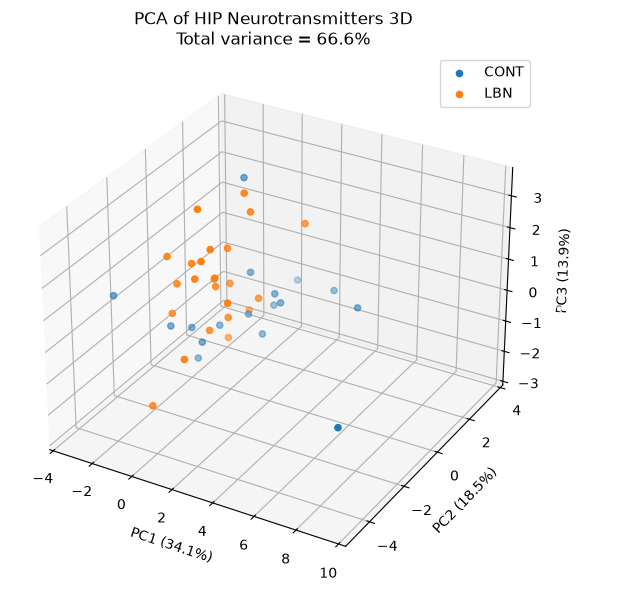

In [50]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==0,0],
    X_adu_hip_pca[Y_adu_hip==0,1],
    X_adu_hip_pca[Y_adu_hip==0,2],
    label="CONT"
)

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==1,0],
    X_adu_hip_pca[Y_adu_hip==1,1],
    X_adu_hip_pca[Y_adu_hip==1,2],
    label="LBN"
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"PCA of HIP Neurotransmitters 3D\nTotal variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%"
)

ax.legend()
fig.subplots_adjust(right=0.85)

plt.tight_layout()
ax.text2D(
    1,
    0.5,
    f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)",
    transform=ax.transAxes,
    color="white"
)
plt.show()

In [51]:
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

In [53]:
print(f"Loadings for PC1:\n{loadings_hip['PC1'].sort_values(key=abs, ascending=False)}")

Loadings for PC1:
Glutamine          0.395297
Tryptophane        0.390000
GABA               0.381479
Glutamate          0.330551
Noradrénaline      0.327201
Kynurénine         0.273607
Tyrosine          -0.268072
Normétanéphrine    0.259924
Adénosine          0.244390
Sérotonine         0.182801
Dopamine          -0.102314
Tyramine          -0.099425
5HTP               0.044818
Name: PC1, dtype: float64


In [54]:
print(f"Loadings for PC2:\n{loadings_hip['PC2'].sort_values(key=abs, ascending=False)}")

Loadings for PC2:
5HTP               0.539148
Sérotonine        -0.391620
Noradrénaline     -0.336696
Dopamine          -0.330156
Tyrosine          -0.280002
Adénosine         -0.273386
Kynurénine         0.273302
Tryptophane        0.232839
Glutamate         -0.198475
Glutamine          0.083757
Normétanéphrine   -0.052261
Tyramine          -0.043865
GABA              -0.021757
Name: PC2, dtype: float64


In [55]:
print(f"Loadings for PC3:\n{loadings_hip['PC3'].sort_values(key=abs, ascending=False)}")

Loadings for PC3:
Normétanéphrine    0.532993
Tyramine           0.385303
Sérotonine        -0.363782
Kynurénine        -0.346728
Adénosine          0.323949
GABA               0.283820
Noradrénaline     -0.222883
Glutamate         -0.214204
Tyrosine          -0.128535
5HTP              -0.093702
Tryptophane       -0.080487
Glutamine          0.043963
Dopamine          -0.011573
Name: PC3, dtype: float64


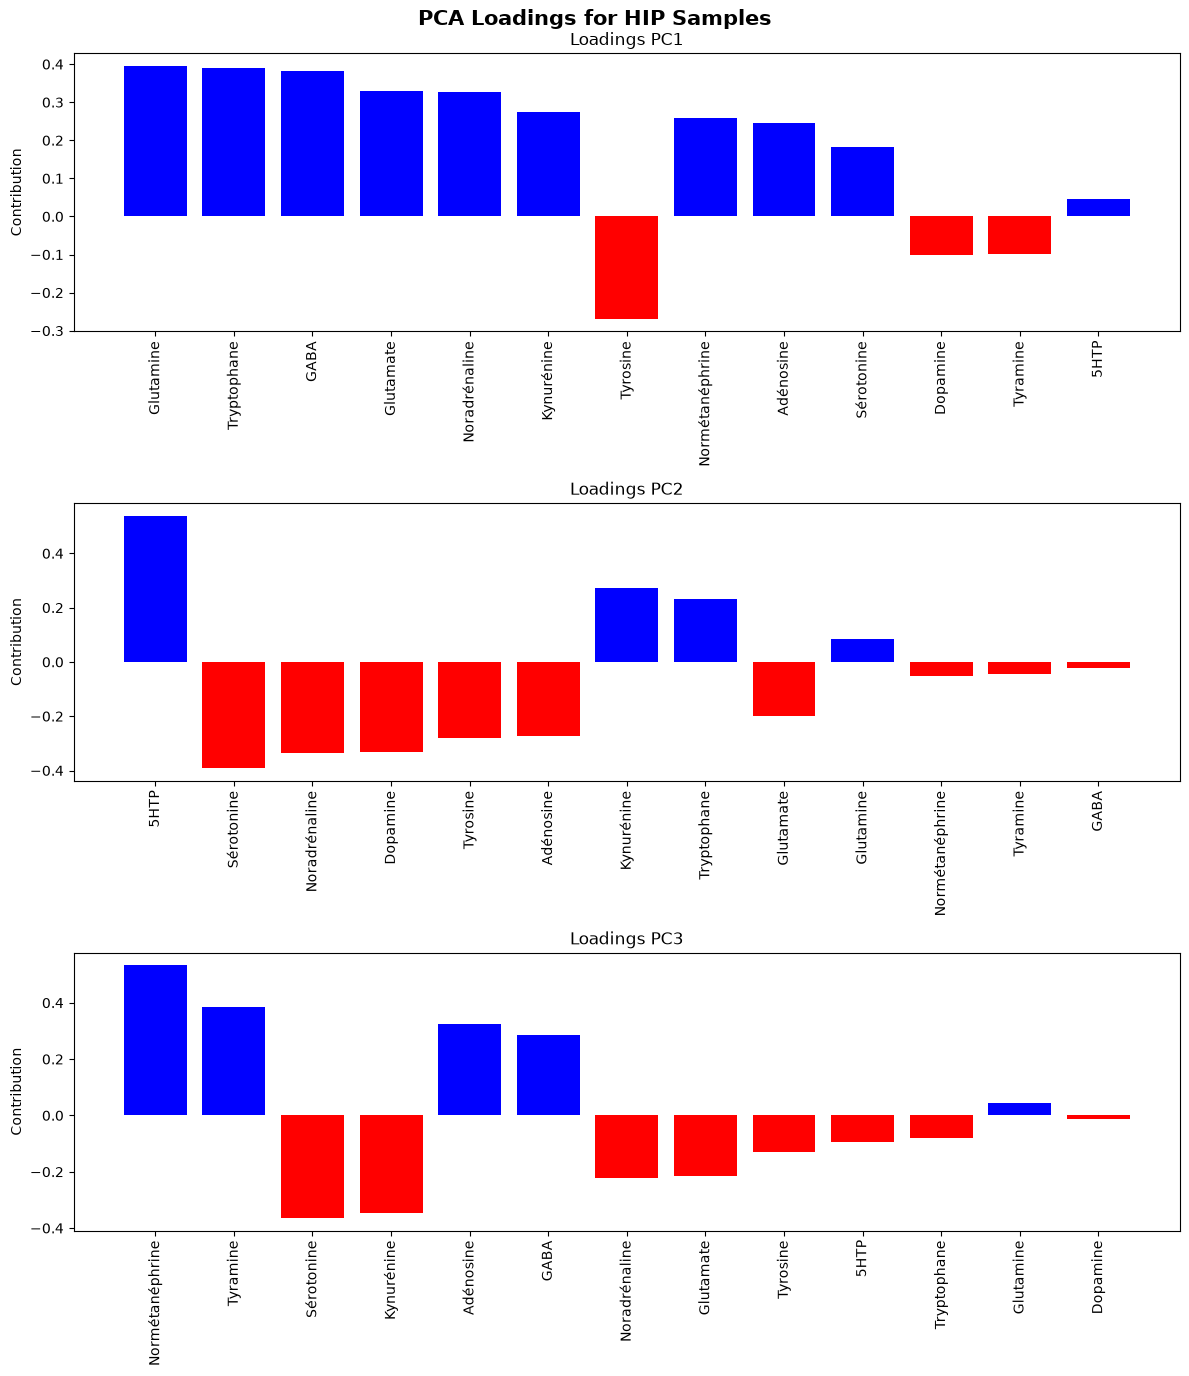

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Loadings PCA
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

# Figure
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
)
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    # tri par valeur absolue
    values = loadings_hip[pc].sort_values(key=abs, ascending=False)
    
    # couleurs selon le signe
    colors = ["red" if v < 0 else "blue" for v in values.values]
    
    axes[i].bar(values.index, values.values, color=colors)
    axes[i].set_title(f"Loadings {pc}")
    axes[i].set_ylabel("Contribution")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

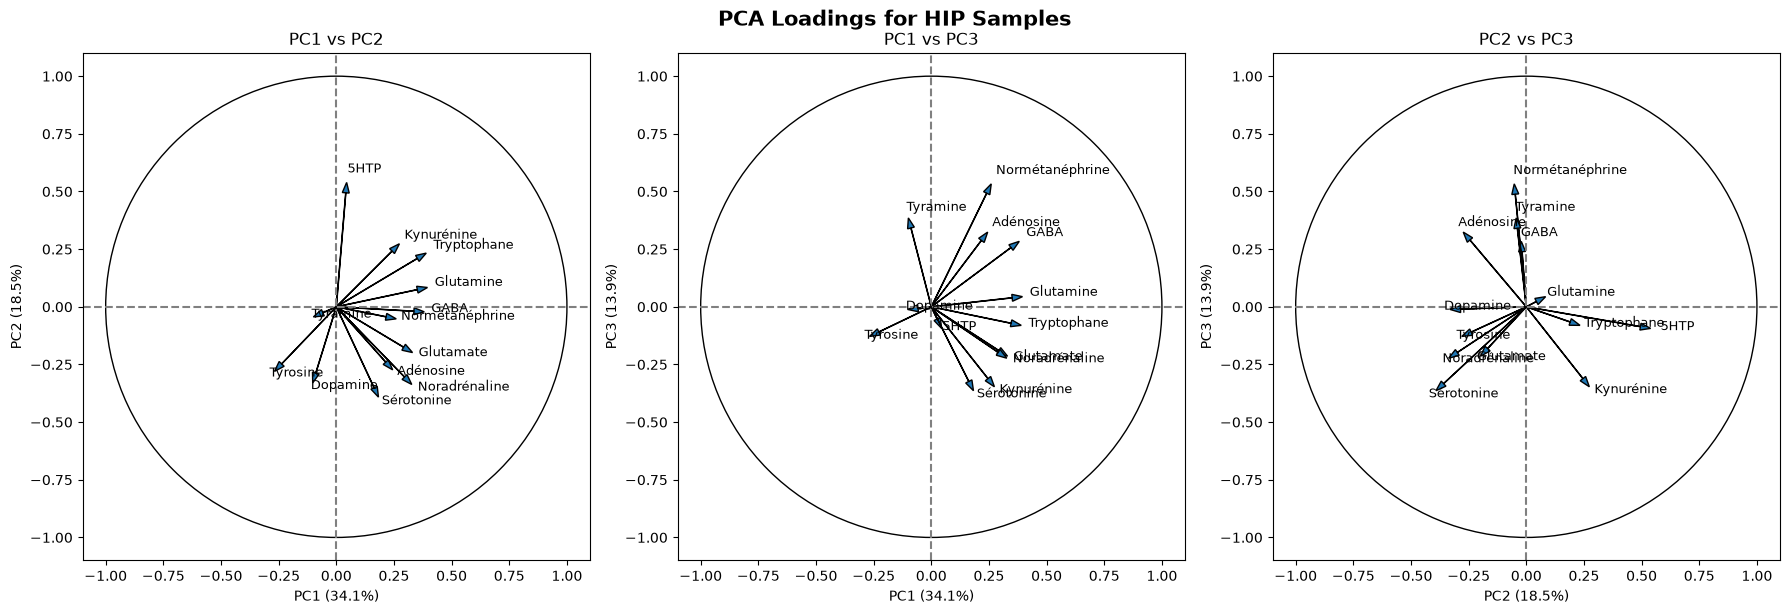

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_hip.index:

        x = loadings_hip.loc[nt, pcx]
        y = loadings_hip.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

### Hierarchical clustering

---

#### For the PFC

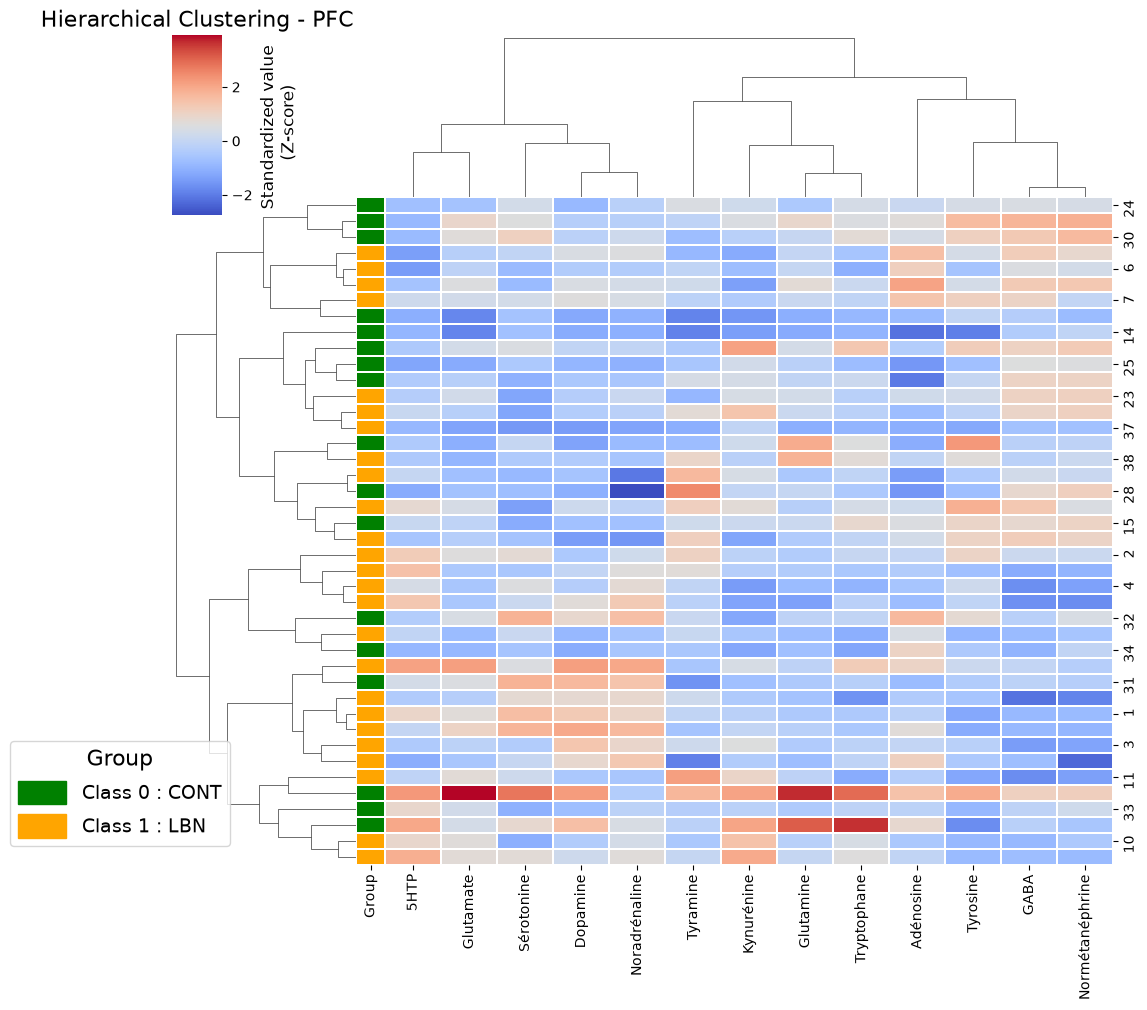

In [ ]:
import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_pfc_log)

row_colors = Y_adu_pfc.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_pfc_log.columns
    ),
    method="complete",
    metric="correlation",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0 : CONT"),
    mpatches.Patch(color="orange", label="Class 1 : LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - PFC", fontsize=16)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="complete",
    metric="correlation",
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1             11       11     22
2              6       14     20
All           17       25     42


---

#### For the HIP

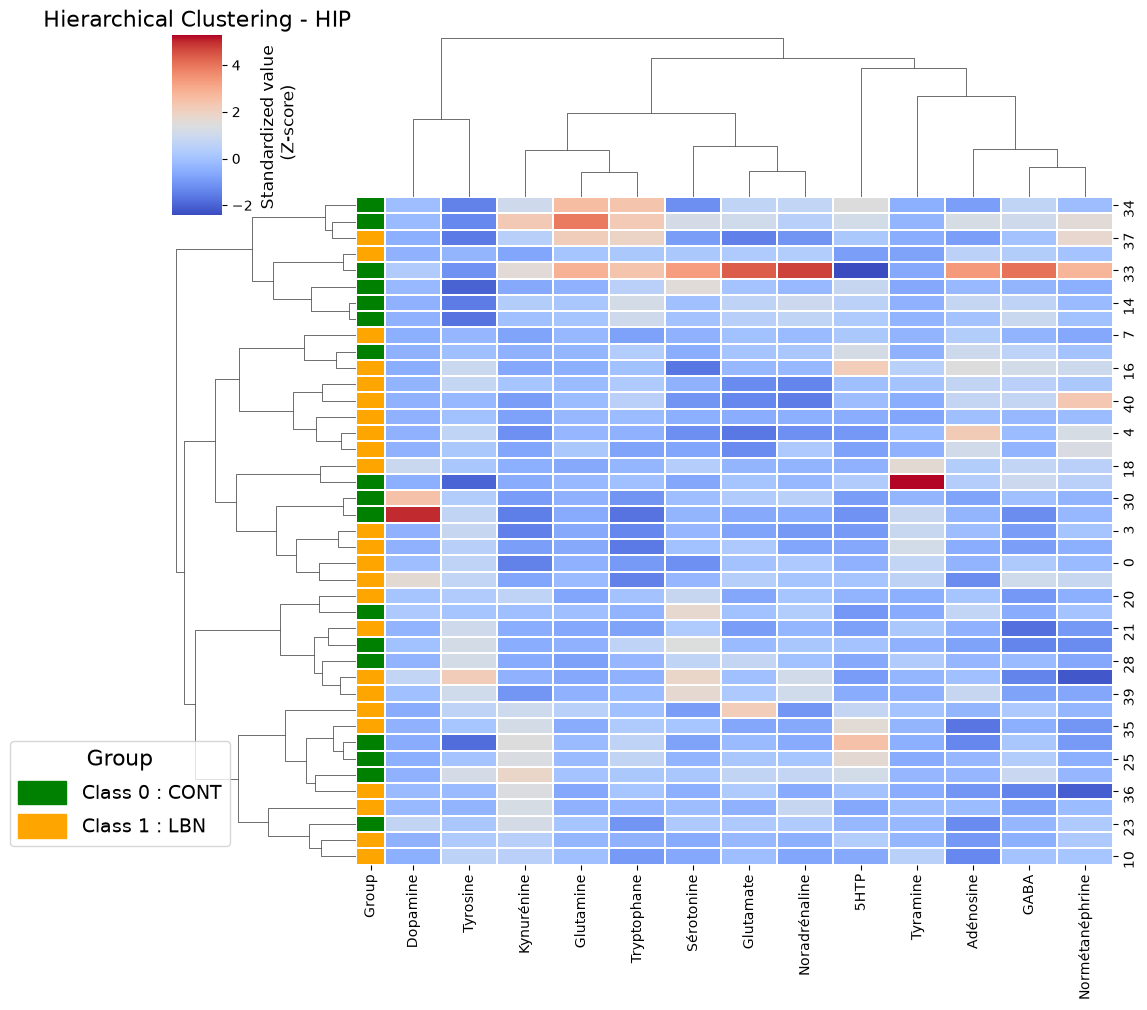

In [ ]:
import matplotlib.patches as mpatches


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_hip_log)

row_colors = Y_adu_hip.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_hip_log.columns
    ),
    method="complete",
    metric="correlation",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0 : CONT"),
    mpatches.Patch(color="orange", label="Class 1 : LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - HIP", fontsize=16)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="complete",
    metric="correlation",
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1              6        2      8
2             11       22     33
All           17       24     41


### Logistic Regression

--- 

#### For the PFC

In [ ]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc"
)

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.737 ± 0.156
Sensitivity = 0.792 ± 0.185
Specificity = 0.657 ± 0.273
AUC         = 0.808 ± 0.160


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

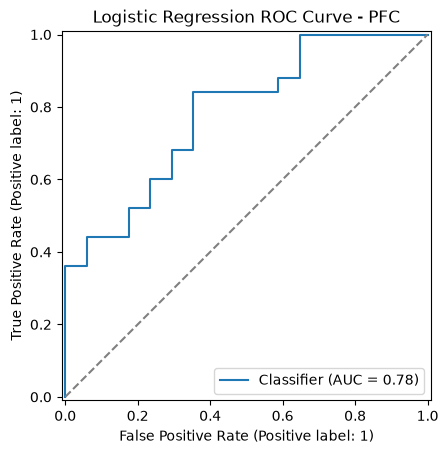

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [ ]:
log_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

coef = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

                 NT  Coefficient
11         Tyramine     0.888677
2          Dopamine     0.600837
1         Adénosine     0.556114
7     Noradrénaline     0.514284
6        Kynurénine     0.296921
0              5HTP     0.290796
3              GABA     0.279290
12         Tyrosine     0.192748
4         Glutamate     0.101199
5         Glutamine    -0.131965
10      Tryptophane    -1.033692
9        Sérotonine    -1.127917
8   Normétanéphrine    -1.308687


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


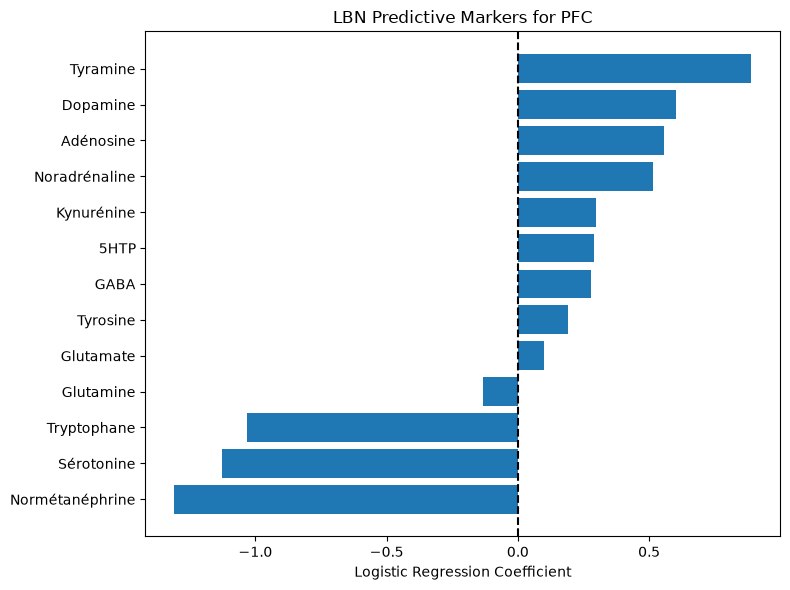

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for PFC")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_pfc_log,
        Y_adu_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.315993,-0.378231,1.045990
Adénosine,0.583752,-0.199966,1.286500
Dopamine,0.553181,-0.104890,1.244260
GABA,0.122994,-0.700956,0.888294
Glutamate,0.181171,-0.502930,0.855374
Glutamine,-0.171535,-0.900043,0.601214
Kynurénine,0.253681,-0.382003,0.889518
Noradrénaline,0.452172,-0.233661,1.189723
Normétanéphrine,-1.172214,-1.733428,-0.624810
Sérotonine,-1.038671,-1.723872,-0.311478


---

#### For the HIP

In [ ]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc"
)

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.641 ± 0.146
Sensitivity = 0.670 ± 0.203
Specificity = 0.602 ± 0.284
AUC         = 0.743 ± 0.159


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

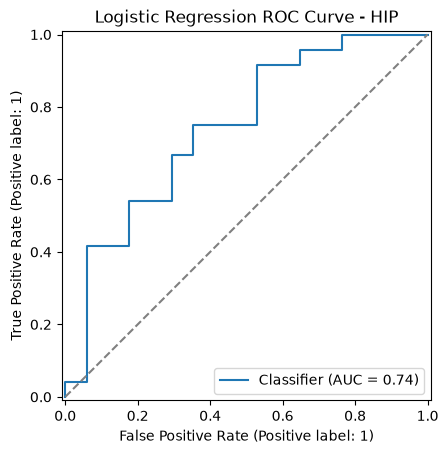

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

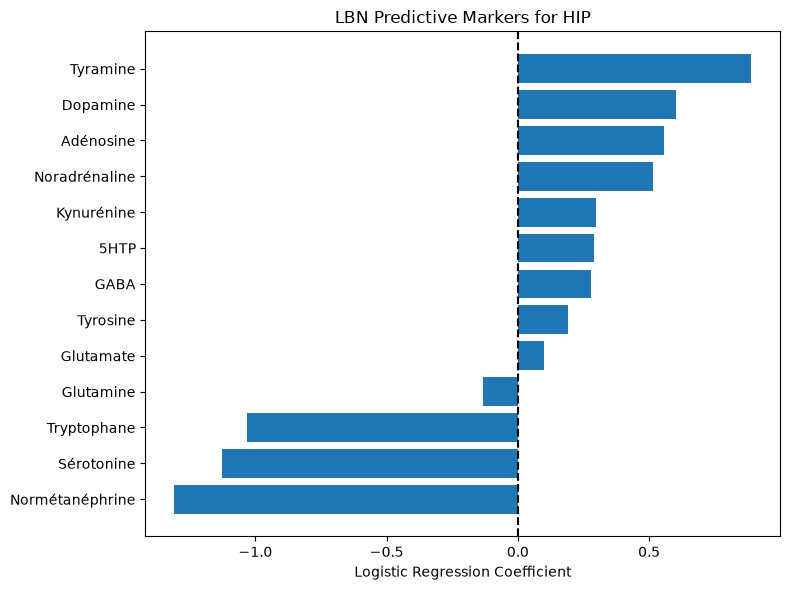

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for HIP")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_hip_log,
        Y_adu_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,-0.670661,-1.315819,0.029290
Adénosine,0.102657,-0.661764,0.916642
Dopamine,-0.931380,-1.771072,0.439853
GABA,-0.316824,-1.102907,0.459353
Glutamate,-0.833459,-1.717838,-0.088737
Glutamine,-0.025380,-0.704407,0.580429
Kynurénine,-0.142692,-0.913571,0.634470
Noradrénaline,-0.641694,-1.366040,0.133636
Normétanéphrine,0.123759,-0.505956,0.886491
Sérotonine,-0.775266,-1.511826,0.022722


### Random Forest

---
#### For the PFC

In [ ]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=2, #Each tree can only make 2 splits.
    min_samples_leaf=4, #Minimum animals at the end of a branch.
    min_samples_split=8, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc" 
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.75  0.5   0.467 0.4   0.867 0.75  0.7   0.533 0.8   0.267 0.9   0.55
 0.6   0.733 0.8   0.45  0.9   0.8   0.6   0.867 0.95  0.7   0.533 0.8
 0.533 0.45  0.6   0.867 0.867 0.733 0.7   0.85  0.733 0.6   0.867 0.5
 1.    0.533 0.6   0.8   0.7   0.8   0.8   0.6   0.8   0.8   0.75  0.867
 0.867 0.4   0.7   0.75  0.933 0.733 0.6   0.65  0.65  0.8   0.6   0.8
 0.25  0.95  0.467 0.867 0.6   0.45  0.4   0.6   0.867 0.8   0.7   0.9
 0.867 0.667 0.533 0.8   0.75  0.533 0.867 0.533 0.65  0.65  0.267 0.733
 0.667 0.65  0.9   0.733 0.533 0.667 0.95  0.45  0.467 1.    0.733 0.4
 0.7   0.933 0.267 1.   ]
Mean AUC = 0.688
SD = 0.178


In [ ]:
rf_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                 NT  Importance
8   Normétanéphrine    0.154772
3              GABA    0.130043
2          Dopamine    0.115278
7     Noradrénaline    0.112799
10      Tryptophane    0.081242
0              5HTP    0.064084
9        Sérotonine    0.061889
1         Adénosine    0.061565
11         Tyramine    0.054772
4         Glutamate    0.048277
5         Glutamine    0.044915
12         Tyrosine    0.037966
6        Kynurénine    0.032399


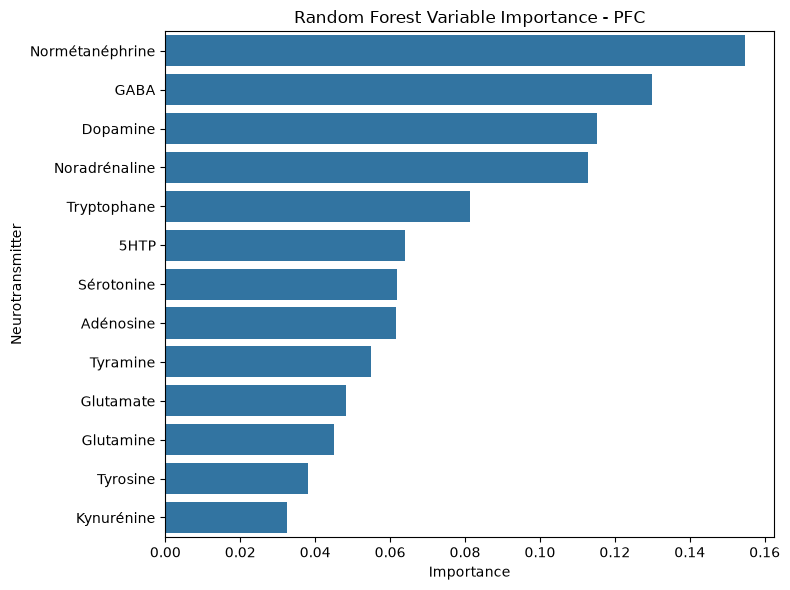

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - PFC")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

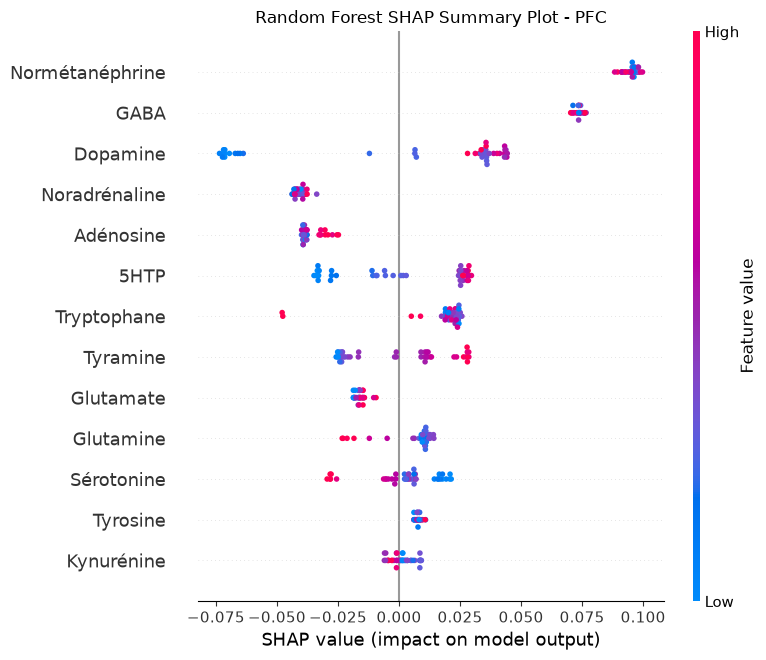

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Original data (no imputation)
X = pd.DataFrame(
    X_adu_pfc_log,
    columns=X_adu_pfc_log.columns
)

# Extract trained Random Forest
rf = rf_pipe.named_steps["rf"]

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Summary plot
shap.summary_plot(
    shap_class1,
    X,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC")
plt.tight_layout()
plt.show()

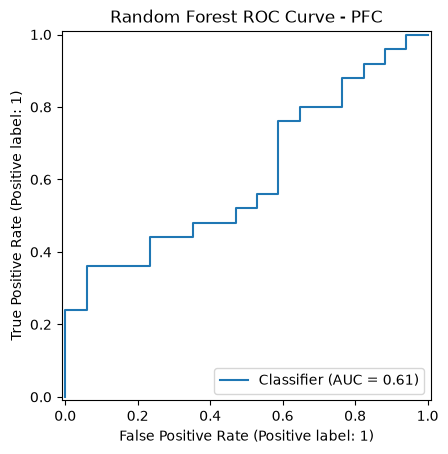

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)

plt.title("Random Forest ROC Curve - PFC")
plt.show()

---

#### For the HIP

In [ ]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=3, #Each tree can only make 2 splits.
    min_samples_leaf=2, #Minimum animals at the end of a branch.
    min_samples_split=4, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.7   0.733 0.867 0.733 0.812 0.65  0.8   0.8   0.8   0.75  0.8   1.
 0.4   0.867 0.75  0.5   0.8   0.8   0.8   1.    0.75  0.533 1.    0.733
 0.938 0.55  0.867 0.467 0.667 0.875 0.75  1.    0.6   0.867 0.75  1.
 0.933 0.867 0.8   0.688 0.55  0.867 1.    0.867 0.625 0.7   0.8   0.867
 0.933 0.625 0.95  0.2   1.    0.867 0.75  0.6   0.733 0.867 0.933 0.75
 0.55  0.933 0.667 0.8   0.625 0.8   0.867 0.667 0.933 0.688 0.75  0.8
 1.    0.8   0.188 0.55  0.667 0.6   0.8   1.    0.95  0.733 0.867 0.733
 0.688 0.75  0.333 0.933 0.733 0.75  0.8   0.6   0.133 1.    1.    0.5
 1.    0.667 0.733 0.688]
Mean AUC = 0.758
SD = 0.179


In [ ]:
rf_pipe.fit(X_adu_hip_log, Y_adu_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                 NT  Importance
4         Glutamate    0.177255
10      Tryptophane    0.155875
7     Noradrénaline    0.131763
12         Tyrosine    0.094071
0              5HTP    0.077442
6        Kynurénine    0.064200
5         Glutamine    0.060843
3              GABA    0.053971
2          Dopamine    0.045260
9        Sérotonine    0.044887
11         Tyramine    0.038217
8   Normétanéphrine    0.032034
1         Adénosine    0.024182


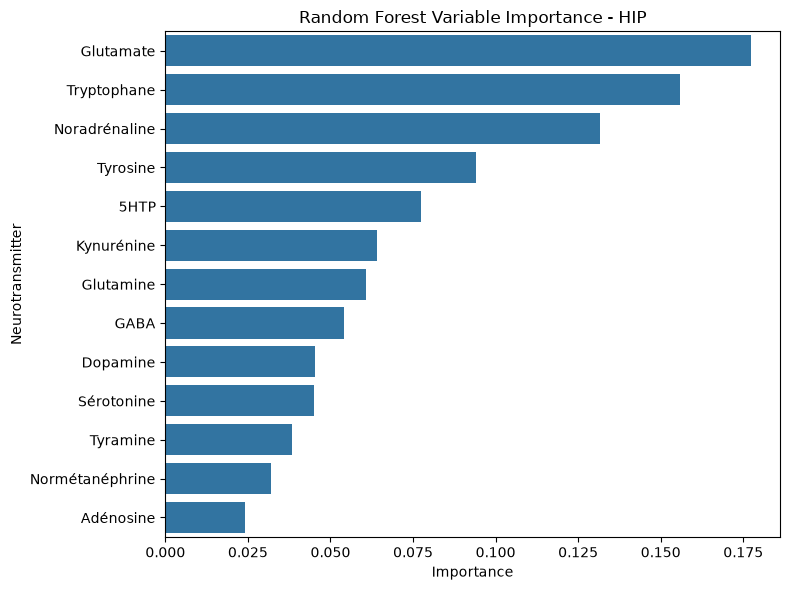

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - HIP")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

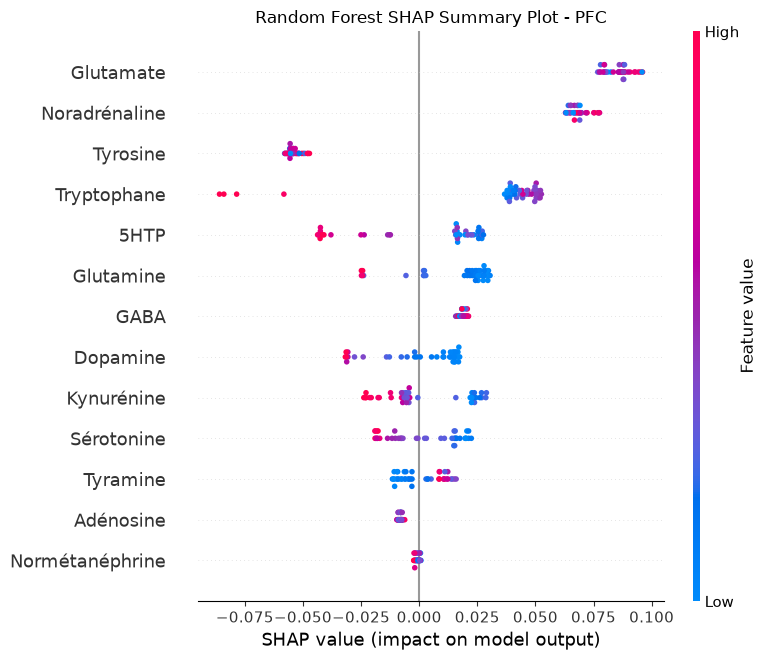

In [ ]:
import shap
import matplotlib.pyplot as plt

# Original data (no imputation)
X = X_adu_hip_log

# Extract trained Random Forest
rf = rf_pipe.named_steps["rf"]

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Summary plot
shap.summary_plot(
    shap_class1,
    X,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC")
plt.tight_layout()
plt.show()

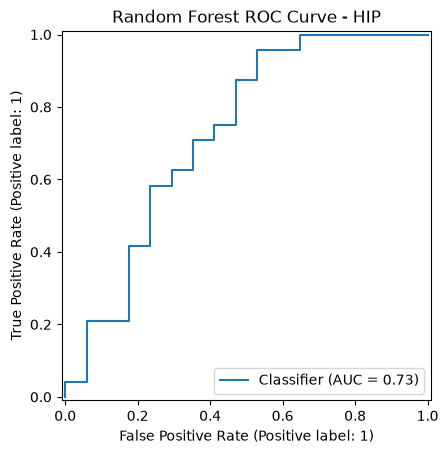

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()